# EDA — Phía **demand** (người đi tìm BĐS)

## Kernel: **Data (local)**

Chọn kernel Jupyter trùng với môi trường bạn dùng cho dữ liệu này (ví dụ **Data (local)**). Trong terminal của *đúng* interpreter đó, cài dependency một lần:

```bash
python -m pip install -r requirements-eda.txt
```

**Định nghĩa demand (theo README):** user có ít nhất một sự kiện tích cực trong `fact_user_events`:
`event_type ∈ {view_phone, contact_chat, other_interaction, contact_zalo, contact_sms}`.

Notebook dùng **DuckDB** đọc Parquet trực tiếp (nhẹ cho máy, thống nhất query). Biểu đồ dùng **matplotlib + seaborn** với palette cố định theo `category`.


---

## RAM trên MacBook Air M1 (8GB)

**Có thể tràn RAM / swap mạnh** nếu quét full `fact_user_events` (~162M dòng) nhiều lần song song với Chrome/Cursor.

Notebook đã cấu hình DuckDB `memory_limit` + giảm `threads`. Các cell nặng (§5–§7) có **sample** — trên M1 8GB nên để `TEMPORAL_SAMPLE_FRAC = 0.05`–`0.1` trước, khi ổn mới chạy full.

| Triệu chứng | Cách xử lý |
|---|---|
| Máy đơ, fan quay | Giảm sample, đóng tab trình duyệt, Restart kernel |
| Kernel chết | Tăng sample hoặc chạy từng cell, không Run All |
| Đủ RAM (16GB+) | Đặt sample = `None` cho kết quả chính xác hơn |


---

## Quy tắc visualize

1. **Chart hiển thị trong output** notebook (`plt.show()` sau mỗi figure).
2. **Trục / màu ưu tiên tỉ lệ %** (share, CVR×100, stacked 100%) — bảng số tuyệt đối vẫn `display()` kèm cột `%`.
3. File PNG vẫn lưu vào `outputs/eda_demand/` để báo cáo.


In [2]:
from __future__ import annotations

import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Cấu hình RAM (MacBook Air M1 8GB) ---
DUCKDB_MEMORY_LIMIT = "2GB"
DUCKDB_THREADS = 2
TEMPORAL_SAMPLE_FRAC = 0.05
ENGAGEMENT_SAMPLE_FRAC = None
QUERY_SAMPLE_FRAC = 0.1

DATA_ROOT = Path.cwd().resolve()
for name in ("dim_listing", "fact_user_events", "fact_listing_snapshot", "fact_post_contact_interactions"):
    if not (DATA_ROOT / name).exists():
        raise FileNotFoundError(
            f"Không thấy thư mục `{name}` trong {DATA_ROOT}. Hãy mở notebook từ thư mục gốc bộ dữ liệu hoặc sửa DATA_ROOT."
        )

OUT_DIR = DATA_ROOT / "outputs" / "eda_demand"
OUT_DIR.mkdir(parents=True, exist_ok=True)

POSITIVE_TYPES = (
    "view_phone",
    "contact_chat",
    "other_interaction",
    "contact_zalo",
    "contact_sms",
)
pos_list = ", ".join(repr(x) for x in POSITIVE_TYPES)

CAT_META = pd.DataFrame(
    [
        (1010, "Phòng trọ / căn hộ cho thuê"),
        (1020, "Căn hộ / chung cư"),
        (1030, "Nhà ở"),
        (1040, "Đất nền / thương mại"),
        (1050, "Dự án mới"),
    ],
    columns=["category", "category_name"],
)

CAT_ORDER = CAT_META["category"].tolist()
PALETTE = {
    1010: "#238b45",
    1020: "#2171b5",
    1030: "#6a51a3",
    1040: "#cb181d",
    1050: "#d94801",
}

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


def pct_share(series: pd.Series) -> pd.Series:
    total = float(series.sum())
    if total == 0:
        return series.astype(float)
    return series / total * 100.0


def pct_row(df: pd.DataFrame) -> pd.DataFrame:
    row_sum = df.sum(axis=1).replace(0, np.nan)
    return df.div(row_sum, axis=0) * 100.0


def show_and_save(name: str, **kwargs):
    """Lưu PNG + hiển thị chart trong notebook output."""
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", **kwargs)
    plt.show()
    print("Saved", path)


save_fig = show_and_save


def order_categories(df: pd.DataFrame, col: str = "category") -> pd.DataFrame:
    df = df.copy()
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[df[col].isin(CAT_ORDER)]
    df[col] = pd.Categorical(df[col].astype(int), categories=CAT_ORDER, ordered=True)
    return df.sort_values(col)


def sample_clause(frac, alias: str = "") -> str:
    if frac is None:
        return ""
    return f"AND random() < {float(frac)}"


con = duckdb.connect(database=":memory:")
con.execute(f"PRAGMA memory_limit='{DUCKDB_MEMORY_LIMIT}'")
con.execute(f"PRAGMA threads={DUCKDB_THREADS}")
con.execute("PRAGMA enable_progress_bar")

print("DATA_ROOT =", DATA_ROOT)
print("DuckDB", duckdb.__version__, "| memory_limit =", DUCKDB_MEMORY_LIMIT, "| threads =", DUCKDB_THREADS)



DATA_ROOT = /Users/dothinh_3112/Downloads/Datathon_Data
DuckDB 1.5.2 | memory_limit = 2GB | threads = 2


## 1. Quy mô & phạm vi thời gian

Đếm nhanh số file Parquet và khoảng `date` (train window theo README: 09/11/2025 → 09/04/2026 — kiểm chứng trên data).

In [3]:
globs = {
    "dim_listing": str(DATA_ROOT / "dim_listing" / "*.parquet"),
    "fact_listing_snapshot": str(DATA_ROOT / "fact_listing_snapshot" / "*.parquet"),
    "fact_post_contact_interactions": str(DATA_ROOT / "fact_post_contact_interactions" / "*.parquet"),
    "fact_user_events": str(DATA_ROOT / "fact_user_events" / "*.parquet"),
}

inventory = []
for label, pattern in globs.items():
    n_files = con.execute(
        "SELECT COUNT(*) FROM glob(?)",
        [pattern],
    ).fetchone()[0]
    inventory.append({"table": label, "parquet_files": int(n_files), "glob": pattern})

inv_df = pd.DataFrame(inventory)
display(inv_df)

ranges = []
for label in ["fact_listing_snapshot", "fact_post_contact_interactions", "fact_user_events"]:
    pattern = globs[label]
    row = con.execute(
        f"""
        SELECT
            ? AS table_name,
            MIN(date) AS min_date,
            MAX(date) AS max_date,
            COUNT(*) AS rows
        FROM read_parquet(?)
        """,
        [label, pattern],
    ).fetchdf()
    ranges.append(row)

range_df = pd.concat(ranges, ignore_index=True)
display(range_df)

events_glob = globs["fact_user_events"]


,table,parquet_files,glob
0,dim_listing,40,/Users/dothinh_3112/Downloads/Datathon_Data/di...
1,fact_listing_snapshot,62,/Users/dothinh_3112/Downloads/Datathon_Data/fa...
2,fact_post_contact_interactions,147,/Users/dothinh_3112/Downloads/Datathon_Data/fa...
3,fact_user_events,500,/Users/dothinh_3112/Downloads/Datathon_Data/fa...


,table_name,min_date,max_date,rows
0,fact_listing_snapshot,2025-11-09,2026-04-09,19762167
1,fact_post_contact_interactions,2025-11-09,2026-04-09,25486445
2,fact_user_events,2025-11-09,2026-04-09,161731336


## 2. Cohort **chỉ demand**: user đã có tương tác tích cực

Từ `fact_user_events`, lấy tập `user_id` distinct có `event_type` thuộc nhóm tích cực (có thể lọc `is_login = 'login'` nếu muốn tránh noise session non-login).

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,is_login,demand_users,pct
0,login,810411,28.803993
1,non-login,2003126,71.196007


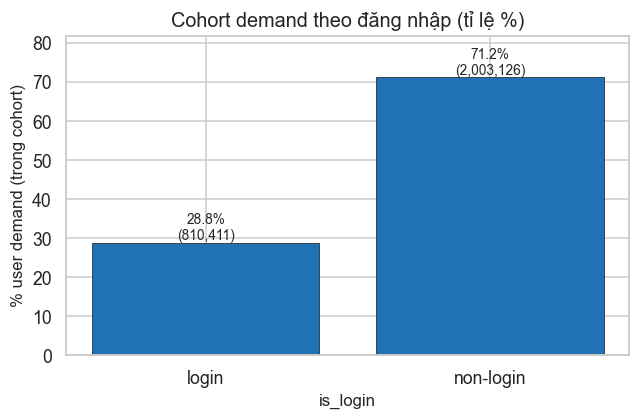

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand/demand_users_by_login.png


In [4]:
demand_counts = con.execute(
    f"""
    WITH base AS (
        SELECT DISTINCT user_id, is_login
        FROM read_parquet(?)
        WHERE event_type IN ({pos_list})
          AND user_id IS NOT NULL
    )
    SELECT is_login, COUNT(*) AS demand_users
    FROM base
    GROUP BY 1
    ORDER BY 1
    """,
    [events_glob],
).fetchdf()

dc = demand_counts.copy()
dc["pct"] = pct_share(dc["demand_users"])
display(dc)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(dc["is_login"], dc["pct"], color="#2171b5", edgecolor="black", linewidth=0.4)
ax.set_ylabel("% user demand (trong cohort)")
ax.set_xlabel("is_login")
ax.set_title("Cohort demand theo đăng nhập (tỉ lệ %)")
ax.set_ylim(0, max(dc["pct"].max() * 1.15, 1))
for bar, p, n in zip(bars, dc["pct"], dc["demand_users"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{p:.1f}%\n({n:,.0f})", ha="center", va="bottom", fontsize=9)
show_and_save("demand_users_by_login.png")



## 3. Demand theo **category** và **device**

Đếm user demand distinct theo `category` của sự kiện tích cực (tin họ quan tâm đủ mạnh để liên hệ).

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

device,Android,Desktop,MSite,iOS
category_name,,,,
Phòng trọ / căn hộ cho thuê,15.2,28.0,41.2,15.6
Căn hộ / chung cư,15.1,19.6,52.4,12.9
Nhà ở,20.3,26.8,31.1,21.7
Đất nền / thương mại,26.1,27.7,35.5,10.7
Dự án mới,12.5,22.6,40.7,24.1


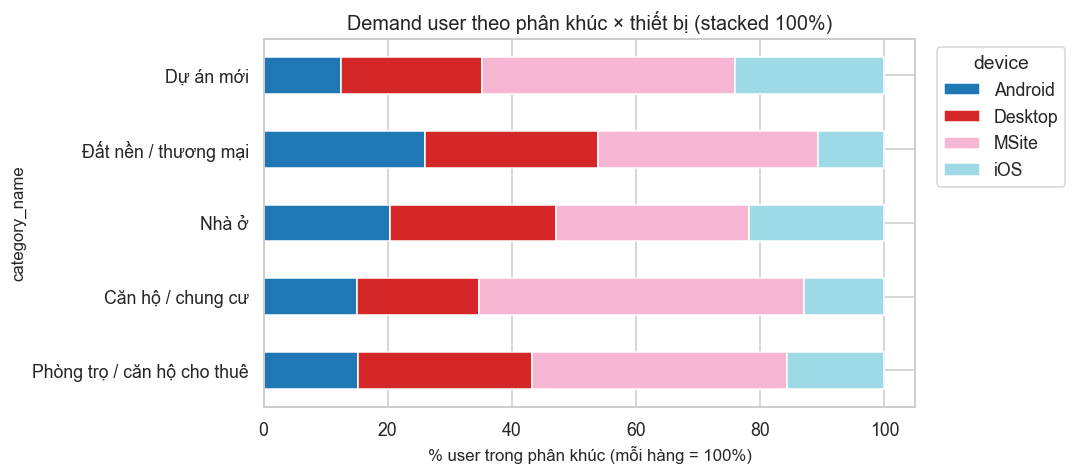

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand/demand_category_device_stacked.png


In [5]:
by_cat_dev = con.execute(
    f"""
    SELECT category, device, APPROX_COUNT_DISTINCT(user_id) AS demand_users
    FROM read_parquet(?)
    WHERE event_type IN ({pos_list})
      AND user_id IS NOT NULL
      AND category IS NOT NULL
    GROUP BY 1, 2
    """,
    [events_glob],
).fetchdf()

by_cat_dev = order_categories(by_cat_dev.merge(CAT_META, on="category", how="left"))
pivot = by_cat_dev.pivot_table(index="category_name", columns="device", values="demand_users", fill_value=0)
_order = CAT_META.set_index("category").reindex(CAT_ORDER)["category_name"].tolist()
pivot = pivot.reindex(_order)
pivot_pct = pct_row(pivot)
display(pivot_pct.round(1))

fig, ax = plt.subplots(figsize=(10, 4.5))
pivot_pct.plot(kind="barh", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Demand user theo phân khúc × thiết bị (stacked 100%)")
ax.set_xlabel("% user trong phân khúc (mỗi hàng = 100%)")
ax.legend(title="device", bbox_to_anchor=(1.02, 1), loc="upper left")
show_and_save("demand_category_device_stacked.png", dpi=150)



## 4. **Funnel**: pageview → tương tác tích cực (theo category)

Tỷ lệ chuyển đổi thô: số sự kiện tích cực / số pageview (cùng bảng events). Đây là proxy cấp **sự kiện**, không phải cấp user-session.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,category,category_name,pageviews,positives,cvr_%
4,1010,Phòng trọ / căn hộ cho thuê,10228587.0,18682535.0,182.650204
0,1020,Căn hộ / chung cư,26941270.0,43337090.0,160.857636
3,1030,Nhà ở,4152213.0,4678090.0,112.664981
2,1040,Đất nền / thương mại,5736925.0,7167351.0,124.933671
1,1050,Dự án mới,18489830.0,22317347.0,120.700661


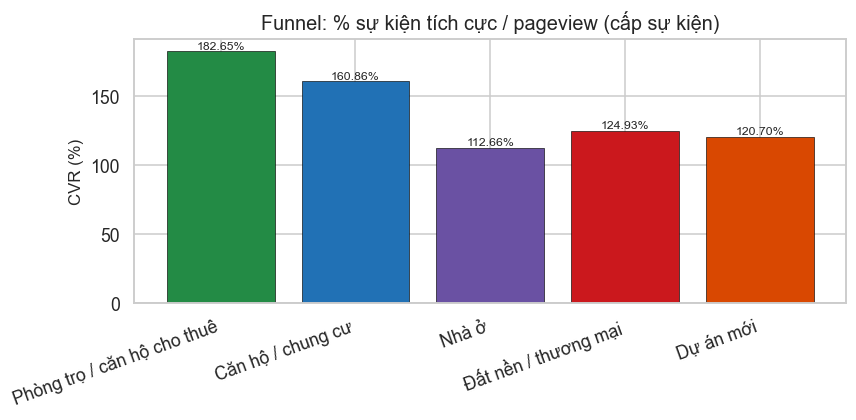

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand/funnel_cvr_by_category.png


In [6]:
_palette = PALETTE

funnel = con.execute(
    f"""
    SELECT
        category,
        SUM(CASE WHEN event_type = 'pageview' THEN 1 ELSE 0 END) AS pageviews,
        SUM(CASE WHEN event_type IN ({pos_list}) THEN 1 ELSE 0 END) AS positives
    FROM read_parquet(?)
    WHERE category IN (1010, 1020, 1030, 1040, 1050)
    GROUP BY 1
    """,
    [events_glob],
).fetchdf()

funnel = order_categories(funnel.merge(CAT_META, on="category", how="left"))
funnel["cvr_pct"] = funnel["positives"] / funnel["pageviews"].replace(0, np.nan) * 100
display(funnel[["category", "category_name", "pageviews", "positives", "cvr_pct"]].rename(columns={"cvr_pct": "cvr_%"}))

fig, ax = plt.subplots(figsize=(8, 4))
colors = [_palette[int(c)] for c in funnel["category"]]
bars = ax.bar(funnel["category_name"], funnel["cvr_pct"], color=colors, edgecolor="black", linewidth=0.4)
ax.set_ylabel("CVR (%)")
ax.set_title("Funnel: % sự kiện tích cực / pageview (cấp sự kiện)")
plt.xticks(rotation=20, ha="right")
for bar, v in zip(bars, funnel["cvr_pct"]):
    if pd.notna(v):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{v:.2f}%", ha="center", va="bottom", fontsize=8)
show_and_save("funnel_cvr_by_category.png", dpi=150)



## 5. **Thời điểm** trong ngày / tuần (mẫu có thể giới hạn để dev nhanh)

Trên full data có thể chậm; cell dưới mặc định `SAMPLE_FRAC=None` (full). Nếu máy yếu, đặt ví dụ `SAMPLE_FRAC=0.05`.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Temporal | sample=0.05 | tổng ô = 4,810,107 events


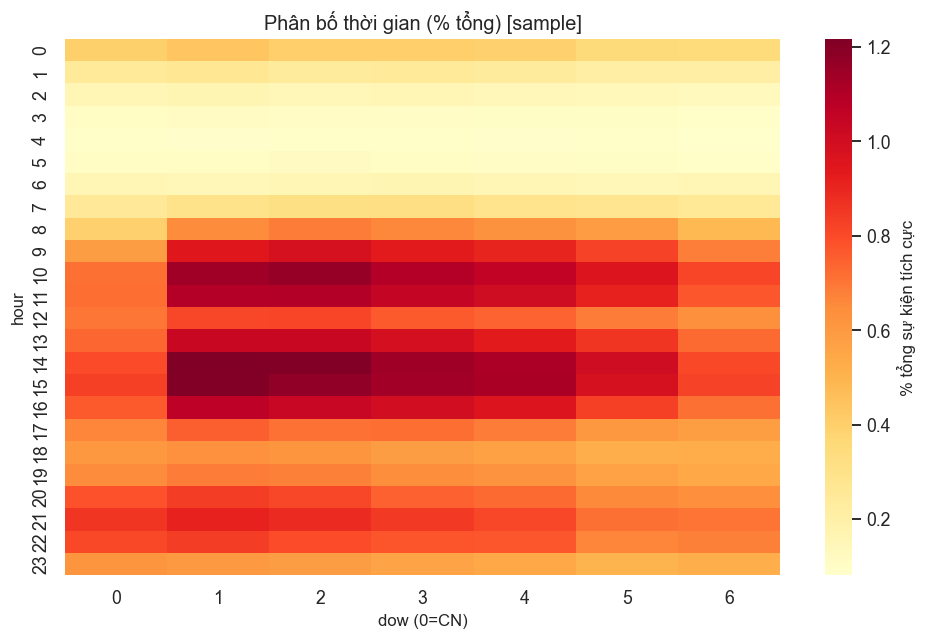

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand/demand_temporal_heatmap.png


In [7]:
SAMPLE_FRAC = TEMPORAL_SAMPLE_FRAC
where_sample = sample_clause(SAMPLE_FRAC)

temporal = con.execute(
    f"""
    SELECT
        EXTRACT(dow FROM event_ts)::INT AS dow,
        EXTRACT(hour FROM event_ts)::INT AS hod,
        COUNT(*)::BIGINT AS pos_events
    FROM read_parquet(?)
    WHERE event_ts IS NOT NULL
      AND event_type IN ({pos_list})
      {where_sample}
    GROUP BY 1, 2
    """,
    [events_glob],
).fetchdf()

heat = temporal.pivot_table(index="hod", columns="dow", values="pos_events", fill_value=0)
total = float(heat.values.sum())
heat_pct = (heat / total * 100.0) if total else heat
print(f"Temporal | sample={SAMPLE_FRAC} | tổng ô = {total:,.0f} events")

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heat_pct, cmap="YlOrRd", ax=ax, cbar_kws={"label": "% tổng sự kiện tích cực"})
ax.set_title(f"Phân bố thời gian (% tổng){' [sample]' if SAMPLE_FRAC else ''}")
ax.set_xlabel("dow (0=CN)")
ax.set_ylabel("hour")
show_and_save("demand_temporal_heatmap.png", dpi=150)



## 6. **Engagement** demand user: phân event theo user (phân vị)

Từ các user có positive event, đếm tổng positive events per user — hiểu heavy tail (user siêu chủ động).

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_demand_users,p50,p90,p99,sample_frac
0,2813537,7.0,69.0,435.0,None


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_cap,users,pct_users
425,426,89,0.003163
426,427,119,0.004230
427,428,80,0.002843
428,429,97,0.003448
429,430,89,0.003163
430,431,91,0.003234
431,432,130,0.004621
432,433,94,0.003341
433,434,111,0.003945
434,435,28207,1.002546


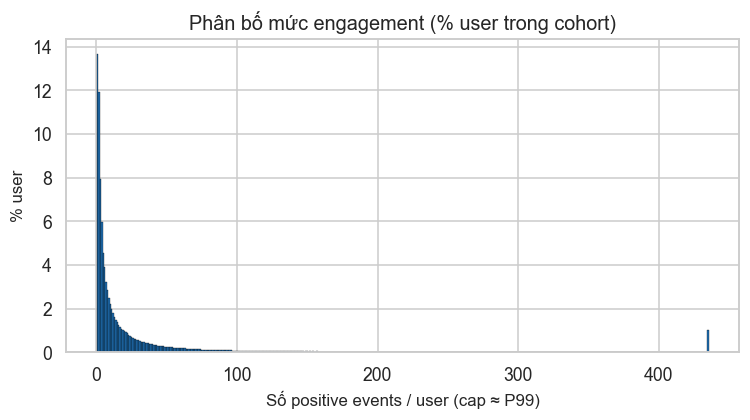

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand/demand_positives_per_user_hist.png


In [8]:
SAMPLE_FRAC = ENGAGEMENT_SAMPLE_FRAC
where_sample = sample_clause(SAMPLE_FRAC)

summary = con.execute(
    f"""
    WITH u AS (
        SELECT COUNT(*)::BIGINT AS n_pos
        FROM read_parquet(?)
        WHERE event_type IN ({pos_list}) AND user_id IS NOT NULL {where_sample}
        GROUP BY user_id
    )
    SELECT
        COUNT(*)::BIGINT AS n_demand_users,
        quantile_cont(n_pos, 0.50) AS p50,
        quantile_cont(n_pos, 0.90) AS p90,
        quantile_cont(n_pos, 0.99) AS p99
    FROM u
    """,
    [events_glob],
).fetchdf()
display(summary.assign(sample_frac=[SAMPLE_FRAC]))

hist = con.execute(
    f"""
    WITH u AS (
        SELECT COUNT(*)::BIGINT AS n_pos
        FROM read_parquet(?)
        WHERE event_type IN ({pos_list}) AND user_id IS NOT NULL {where_sample}
        GROUP BY user_id
    ), p AS (SELECT quantile_cont(n_pos, 0.99) AS p99 FROM u)
    SELECT least(u.n_pos, CAST(CEIL((SELECT p99 FROM p)) AS BIGINT)) AS n_cap,
           COUNT(*)::BIGINT AS users
    FROM u
    GROUP BY 1 ORDER BY 1
    """,
    [events_glob],
).fetchdf()

hist["pct_users"] = pct_share(hist["users"])
display(hist[["n_cap", "users", "pct_users"]].tail(10))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(hist["n_cap"], hist["pct_users"], width=1.0, color="#2171b5", edgecolor="black", linewidth=0.2)
ax.set_title("Phân bố mức engagement (% user trong cohort)")
ax.set_xlabel("Số positive events / user (cap ≈ P99)")
ax.set_ylabel("% user")
show_and_save("demand_positives_per_user_hist.png", dpi=150)



## 7. **Ý định tìm kiếm** (query) — chỉ pageview có `query`

Top query có thể nhiễu; chỉ mang tính khám phá. Có thể lọc `LENGTH(query) > N`.

,query,n,pct
0,phòng trọ,20432,19.408401
1,trọ,11930,11.332333
2,cho thuê phòng trọ ở tp hồ chí minh,11761,11.171799
3,nhà nguyên căn,6304,5.988183
4,nhà trọ,6008,5.707012
5,mặt bằng,5381,5.111424
6,none,5325,5.058229
7,chung cư,3240,3.077683
8,cho thuê phòng trọ,2407,2.286414
9,cho thuê nhà ở ở tp hồ chí minh,2316,2.199973


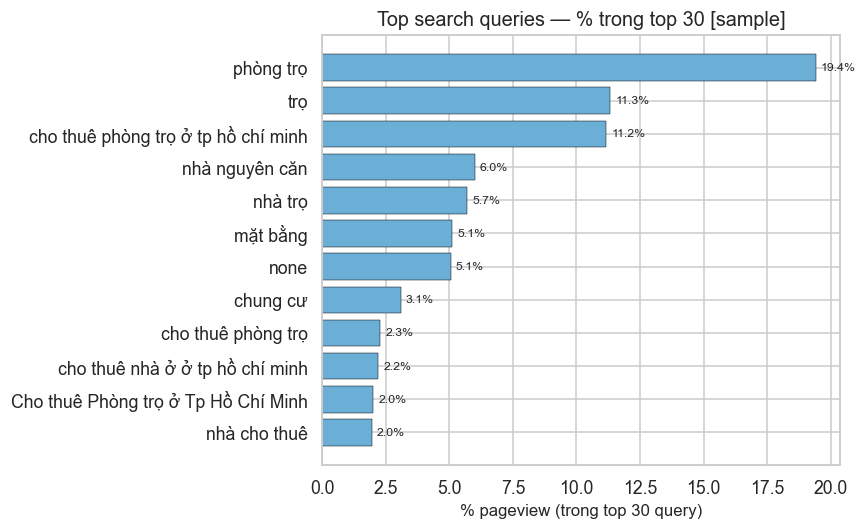

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand/top_search_queries.png


In [9]:
where_sample = sample_clause(QUERY_SAMPLE_FRAC)

top_q = con.execute(
    f"""
    SELECT query, COUNT(*)::BIGINT AS n
    FROM read_parquet(?)
    WHERE event_type = 'pageview'
      AND query IS NOT NULL AND TRIM(CAST(query AS VARCHAR)) <> ''
      {where_sample}
    GROUP BY 1 ORDER BY n DESC LIMIT 30
    """,
    [events_glob],
).fetchdf()

top_q["pct"] = pct_share(top_q["n"])
display(top_q.head(15)[["query", "n", "pct"]])

plot_df = top_q.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df["query"].astype(str), plot_df["pct"], color="#6baed6", edgecolor="black", linewidth=0.3)
ax.set_title(f"Top search queries — % trong top 30{' [sample]' if QUERY_SAMPLE_FRAC else ''}")
ax.set_xlabel("% pageview (trong top 30 query)")
for y, p in enumerate(plot_df["pct"]):
    ax.text(p + 0.2, y, f"{p:.1f}%", va="center", fontsize=8)
show_and_save("top_search_queries.png", dpi=150)



## 8. **Loại** tương tác tích cực (demand intent mix)

Phân bổ `event_type` trong nhóm tích cực — xem kênh liên hệ nào dominate theo phân khúc.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

event_type,contact_chat,contact_sms,contact_zalo,other_interaction,view_phone
category_name,,,,,
Phòng trọ / căn hộ cho thuê,1.1,0.1,0.3,95.3,3.2
Căn hộ / chung cư,0.9,0.1,0.2,94.4,4.4
Nhà ở,1.1,0.1,0.2,92.3,6.3
Đất nền / thương mại,1.1,0.2,0.2,92.1,6.4
Dự án mới,1.7,0.2,0.3,94.3,3.5


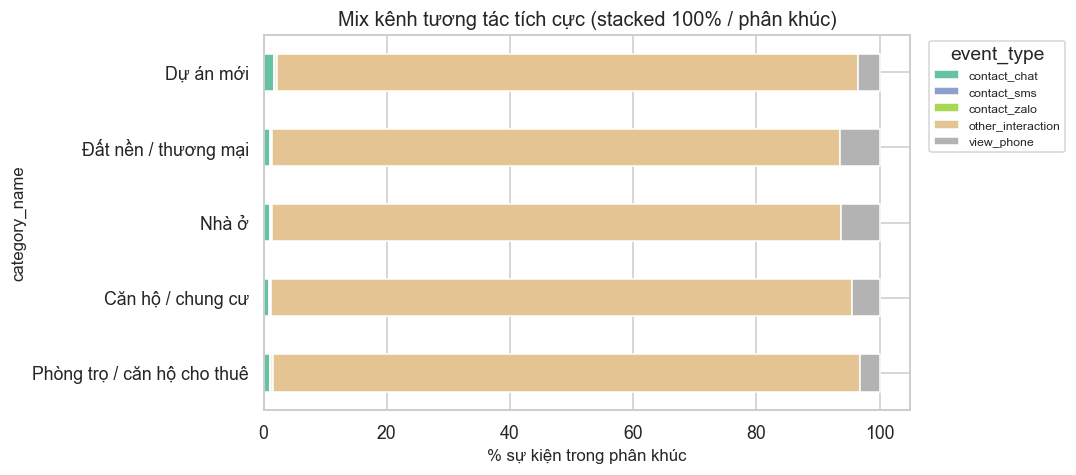

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand/demand_positive_etype_mix.png


In [10]:
etype = con.execute(
    f"""
    SELECT category, event_type, COUNT(*)::BIGINT AS n
    FROM read_parquet(?)
    WHERE event_type IN ({pos_list})
      AND category IN (1010, 1020, 1030, 1040, 1050)
    GROUP BY 1, 2
    """,
    [events_glob],
).fetchdf()

etype = etype.merge(CAT_META, on="category", how="left")
pivot = etype.pivot_table(index="category_name", columns="event_type", values="n", fill_value=0)
pivot = pivot.reindex(CAT_META.set_index("category").reindex(CAT_ORDER)["category_name"].tolist())
pivot_pct = pct_row(pivot)
display(pivot_pct.round(1))

fig, ax = plt.subplots(figsize=(10, 4.5))
pivot_pct.plot(kind="barh", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Mix kênh tương tác tích cực (stacked 100% / phân khúc)")
ax.set_xlabel("% sự kiện trong phân khúc")
ax.legend(title="event_type", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
show_and_save("demand_positive_etype_mix.png", dpi=150)



## 9. **Địa lý** — top `city_name` (sự kiện tích cực)

Aggregate trong DuckDB; chỉ kéo top 15 city về pandas.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,city_name,pos_events,pct
0,Tp Hồ Chí Minh,72229805,76.423103
1,Hà Nội,5760579,6.095009
2,Đà Nẵng,5658464,5.986966
3,Bình Dương,3966567,4.196846
4,Đồng Nai,1460899,1.545711
5,Cần Thơ,1240801,1.312836
6,Long An,1043506,1.104087
7,Bà Rịa - Vũng Tàu,826263,0.874232
8,Lâm Đồng,573995,0.607318
9,Khánh Hòa,502660,0.531842


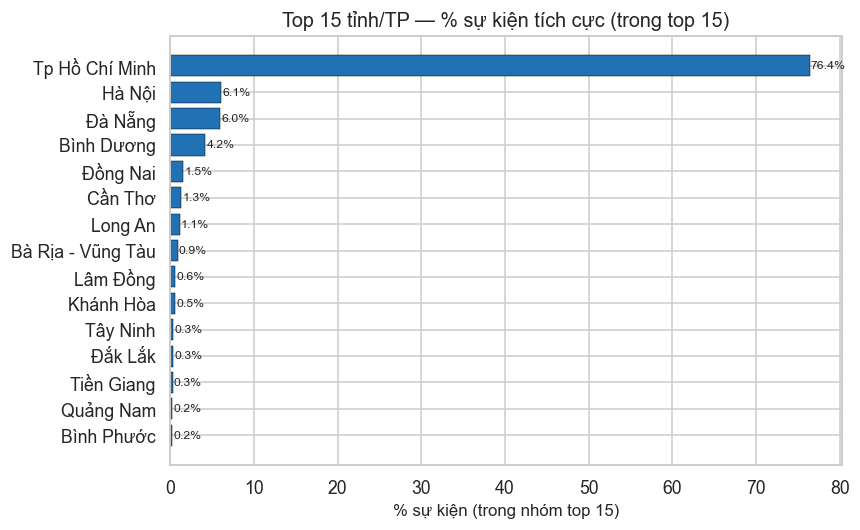

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand/demand_top_cities.png


In [11]:
top_city = con.execute(
    f"""
    SELECT city_name, COUNT(*)::BIGINT AS pos_events
    FROM read_parquet(?)
    WHERE event_type IN ({pos_list})
      AND city_name IS NOT NULL AND TRIM(city_name) <> ''
    GROUP BY 1 ORDER BY pos_events DESC LIMIT 15
    """,
    [events_glob],
).fetchdf()

top_city["pct"] = pct_share(top_city["pos_events"])
display(top_city)

plot_df = top_city.iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df["city_name"], plot_df["pct"], color="#2171b5", edgecolor="black", linewidth=0.3)
ax.set_title("Top 15 tỉnh/TP — % sự kiện tích cực (trong top 15)")
ax.set_xlabel("% sự kiện (trong nhóm top 15)")
for y, p in enumerate(plot_df["pct"]):
    ax.text(p + 0.15, y, f"{p:.1f}%", va="center", fontsize=8)
show_and_save("demand_top_cities.png", dpi=150)

